✓ Repo cloned
✓ File paths set
✓ Envelope: LH 53.0% | EC 47.0%
✓ Fleet sizing
  140°F full system: 5 units
  170°F full system: 4 units
  140°F LH only:     3 units
  170°F EC only:     2 units
✓ Data: 8,760 hours | OAT 16.8–80.6°F | Peak load 378k BTU/hr
✓ All 6 scenarios calculated

      Scenario                                          Add kWh   Peak kW
  ----------------------------------------------------------------------
  S1  Full High-temp ASHP (170°F) — fully electric      146,074      85.6
  S2  Full Low-temp ASHP (140°F) — fully electric       103,814      69.3
  S3  High-temp ASHP (170°F) + propane top-off          146,074      85.6
  S4  High-temp ASHP (170°F) + electric boiler top-off    146,231      88.5
  S5  Low-temp ASHP (140°F) + propane top-off           103,814      69.3
  S6  Low-temp ASHP (140°F) + electric boiler top-off    103,814      69.3

✓ 6 CSV files saved to ../output/
  Format: hour (1–8760) | total_kw


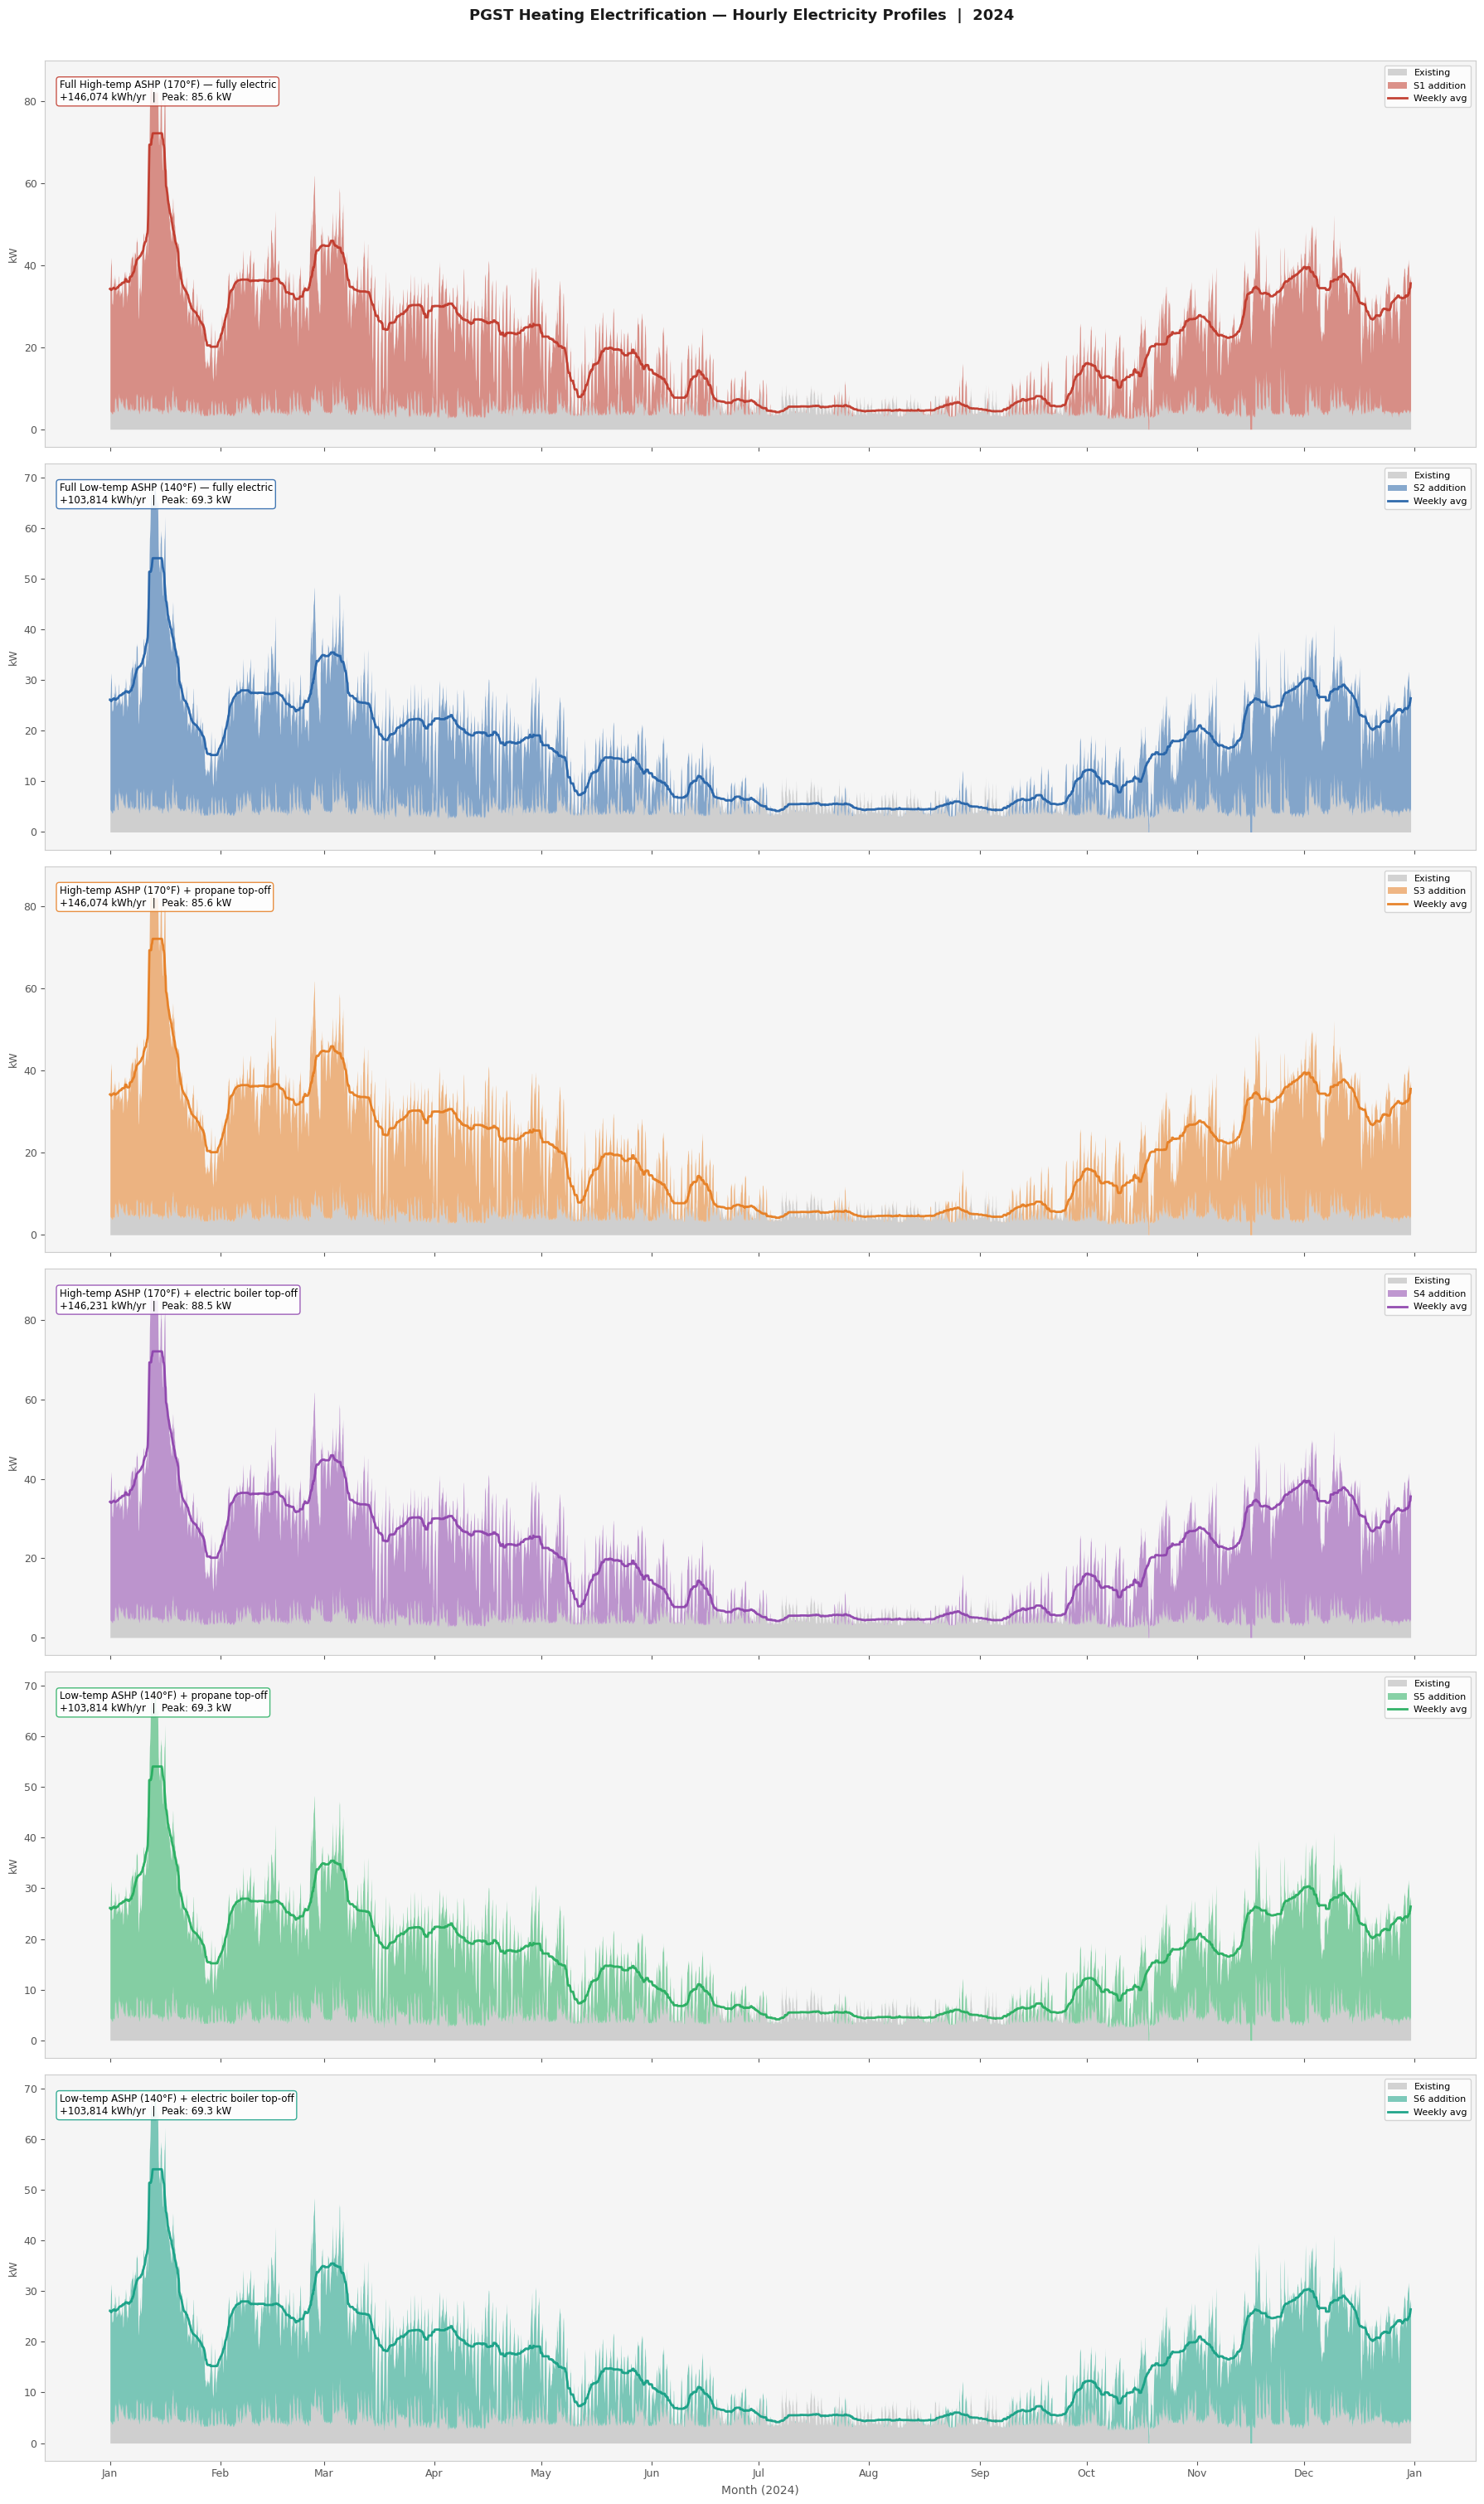

✓ Saved: ../output/scenario_profiles.png


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  PGST Heat Pump Electricity Profile Generator                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── CELL 1: Setup & Clone Repo ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.interpolate import interp1d
from math import ceil
import os, warnings
warnings.filterwarnings("ignore")

os.system("rm -rf PGST")
os.system("git clone --quiet https://github.com/mickdeines/PGST/")
os.chdir("PGST")
os.makedirs("../output", exist_ok=True)
print("✓ Repo cloned")

# %%
# ── CELL 2: FILE INPUTS ───────────────────────────────────────────────────────

F_TEMP   = "ERA5 Hourly Temperatures 2015-2026.csv"
COL_DT   = "time_pacific"
COL_TEMP = "t2m_F"

F_LOAD   = "(REopt) 2024 Boiler Fixed Controls Input Load (MMBtu).csv"
COL_LOAD = "Heating Load (MMBtu/hr)"

F_ELEC   = "(REopt) 2024 BAU Electricity Load Profile.csv"
COL_ELEC = "Load (kW)"

OUT_DIR  = "../output"
print("✓ File paths set")

# %%
# ── CELL 3: BUILDING ENVELOPE ─────────────────────────────────────────────────
# Used for Hybrid scenarios only — splits load by envelope area

LH_ROOF  = 6_000;  LH_WALL1 = 1_200;  LH_WALL2 = 1_200
LH_WALL3 =   800;  LH_WALL4 =   800

EC_ROOF  = 4_060;  EC_WALL1 = 1_500;  EC_WALL2 = 1_500
EC_WALL3 =   900;  EC_WALL4 =   900

LH_ENV  = LH_ROOF + LH_WALL1 + LH_WALL2 + LH_WALL3 + LH_WALL4
EC_ENV  = EC_ROOF + EC_WALL1 + EC_WALL2 + EC_WALL3 + EC_WALL4
LH_FRAC = LH_ENV / (LH_ENV + EC_ENV)
EC_FRAC = 1 - LH_FRAC

print(f"✓ Envelope: LH {LH_FRAC:.1%} | EC {EC_FRAC:.1%}")

# %%
# ── CELL 4: HEAT PUMP SPECS ───────────────────────────────────────────────────

NYLE_140 = {
    80: (290_900, 3.3), 70: (256_450, 3.0), 60: (222_000, 2.7),
    50: (187_920, 2.5), 35: (136_800, 2.1), 20: (101_160, 1.8),
    10: ( 77_400, 1.6),
}
NYLE_170 = {
    80: (243_300, 2.7), 70: (212_850, 2.2), 60: (182_400, 1.8),
    50: (153_550, 1.7), 40: (124_700, 1.7), 30: ( 92_000, 1.4),
}

NYLE_140_MIN = 10   # °F hard floor for 140°F LWT
NYLE_170_MIN = 30   # °F — below this, clamp to 30°F performance

BOILER_OUTPUT_BTU = 378_000 * 0.831   # ~314k BTU/hr — sizing basis

def make_fns(spec):
    t = sorted(spec.keys())
    c = [spec[x][0] for x in t]
    p = [spec[x][1] for x in t]
    return (interp1d(t, c, kind='linear', fill_value=(c[0],c[-1]), bounds_error=False),
            interp1d(t, p, kind='linear', fill_value=(p[0],p[-1]), bounds_error=False))

cap_140, cop_140 = make_fns(NYLE_140)
cap_170, cop_170 = make_fns(NYLE_170)

# Fleet sizing
units_140      = ceil(BOILER_OUTPUT_BTU / float(cap_140(NYLE_140_MIN)))
units_170      = ceil(BOILER_OUTPUT_BTU / float(cap_170(NYLE_170_MIN)))
units_140_lh   = ceil(BOILER_OUTPUT_BTU * LH_FRAC / float(cap_140(NYLE_140_MIN)))
units_170_ec   = ceil(BOILER_OUTPUT_BTU * EC_FRAC / float(cap_170(NYLE_170_MIN)))

print(f"✓ Fleet sizing")
print(f"  140°F full system: {units_140} units")
print(f"  170°F full system: {units_170} units")
print(f"  140°F LH only:     {units_140_lh} units")
print(f"  170°F EC only:     {units_170_ec} units")

# %%
# ── CELL 5: LOAD DATA ─────────────────────────────────────────────────────────

wx = pd.read_csv(F_TEMP)
wx[COL_DT] = pd.to_datetime(wx[COL_DT], utc=True)
wx24 = wx[wx[COL_DT].dt.year == 2024].reset_index(drop=True)

load = pd.read_csv(F_LOAD)
load.columns = [c.strip() for c in load.columns]

elec = pd.read_csv(F_ELEC)
elec.columns = [c.strip() for c in elec.columns]

n = min(len(wx24), len(load), len(elec))

oat_f       = wx24[COL_TEMP].values[:n]
load_btu    = load[COL_LOAD].values[:n] * 1e6
existing_kw = elec[COL_ELEC].values[:n]
datetimes   = pd.to_datetime(wx24[COL_DT].values[:n])

print(f"✓ Data: {n:,} hours | OAT {oat_f.min():.1f}–{oat_f.max():.1f}°F | "
      f"Peak load {load_btu.max()/1000:.0f}k BTU/hr")

# %%
# ── CELL 6: SCENARIO CALCULATIONS ────────────────────────────────────────────
#
# S1 — Full High-temp ASHP (170°F LWT), fully electric
#      HP serves full load; below 30°F clamps to 30°F performance (still runs)
#
# S2 — Full Low-temp ASHP (140°F LWT), fully electric
#      HP serves full load; below 10°F clamps to 10°F performance (still runs)
#
# S3 — High-temp ASHP (170°F LWT) + Propane top-off
#      HP serves load it can handle; propane covers what exceeds fleet capacity
#
# S4 — High-temp ASHP (170°F LWT) + Electric boiler top-off
#      HP serves load it can handle; electric boiler (COP=1) covers remainder
#
# S5 — Low-temp ASHP (140°F LWT) + Propane top-off
#      HP serves load it can handle; propane covers what exceeds fleet capacity
#
# S6 — Low-temp ASHP (140°F LWT) + Electric boiler top-off
#      HP serves load it can handle; electric boiler (COP=1) covers remainder

keys = ['S1','S2','S3','S4','S5','S6']
add_kw = {k: np.zeros(n) for k in keys}

for i in range(n):
    oat = oat_f[i]
    btu = load_btu[i]
    if btu <= 0:
        continue

    # Clamped OAT for each LWT (never extrapolates below spec floor)
    oat_170 = max(oat, NYLE_170_MIN)   # clamp at 30°F
    oat_140 = max(oat, NYLE_140_MIN)   # clamp at 10°F

    # Fleet capacities at current (clamped) OAT
    fleet_cap_170 = units_170    * float(cap_170(oat_170))
    fleet_cap_140 = units_140    * float(cap_140(oat_140))

    # COP at current (clamped) OAT
    c170 = float(cop_170(oat_170))
    c140 = float(cop_140(oat_140))

    # ── S1: Full high-temp HP, fully electric ─────────────────────────────────
    btu_hp = min(btu, fleet_cap_170)
    add_kw['S1'][i] = (btu_hp / 3412.14) / c170

    # ── S2: Full low-temp HP, fully electric ──────────────────────────────────
    btu_hp = min(btu, fleet_cap_140)
    add_kw['S2'][i] = (btu_hp / 3412.14) / c140

    # ── S3: High-temp HP + propane top-off ────────────────────────────────────
    # HP covers what it can; propane covers excess (no extra electricity)
    btu_hp = min(btu, fleet_cap_170)
    add_kw['S3'][i] = (btu_hp / 3412.14) / c170

    # ── S4: High-temp HP + electric boiler top-off ────────────────────────────
    btu_hp      = min(btu, fleet_cap_170)
    btu_backup  = max(0, btu - fleet_cap_170)
    add_kw['S4'][i] = (btu_hp / 3412.14) / c170 + btu_backup / 3412.14

    # ── S5: Low-temp HP + propane top-off ─────────────────────────────────────
    btu_hp = min(btu, fleet_cap_140)
    add_kw['S5'][i] = (btu_hp / 3412.14) / c140

    # ── S6: Low-temp HP + electric boiler top-off ─────────────────────────────
    btu_hp      = min(btu, fleet_cap_140)
    btu_backup  = max(0, btu - fleet_cap_140)
    add_kw['S6'][i] = (btu_hp / 3412.14) / c140 + btu_backup / 3412.14

print("✓ All 6 scenarios calculated")

# %%
# ── CELL 7: EXPORT CSVs ───────────────────────────────────────────────────────

scenario_labels = {
    'S1': 'Full High-temp ASHP (170°F) — fully electric',
    'S2': 'Full Low-temp ASHP (140°F) — fully electric',
    'S3': 'High-temp ASHP (170°F) + propane top-off',
    'S4': 'High-temp ASHP (170°F) + electric boiler top-off',
    'S5': 'Low-temp ASHP (140°F) + propane top-off',
    'S6': 'Low-temp ASHP (140°F) + electric boiler top-off',
}
filenames = {
    'S1': 'electricity_S1_hightemp_full.csv',
    'S2': 'electricity_S2_lowtemp_full.csv',
    'S3': 'electricity_S3_hightemp_propane.csv',
    'S4': 'electricity_S4_hightemp_electric.csv',
    'S5': 'electricity_S5_lowtemp_propane.csv',
    'S6': 'electricity_S6_lowtemp_electric.csv',
}

print(f"\n{'='*72}")
print(f"  {'':3} {'Scenario':<46} {'Add kWh':>10}  {'Peak kW':>8}")
print(f"  {'-'*70}")

for key in keys:
    total_kw = existing_kw + add_kw[key]
    pd.DataFrame({
        'hour':     range(1, n + 1),
        'total_kw': total_kw,
    }).to_csv(f'{OUT_DIR}/{filenames[key]}', index=False)
    print(f"  {key}  {scenario_labels[key]:<46} "
          f"{add_kw[key].sum():>10,.0f}  {total_kw.max():>8.1f}")

print(f"\n✓ 6 CSV files saved to {OUT_DIR}/")
print(f"  Format: hour (1–{n}) | total_kw")

# %%
# ── CELL 8: PLOT ──────────────────────────────────────────────────────────────

COLORS = {
    'S1':'#c0392b', 'S2':'#2563a8',
    'S3':'#e67e22', 'S4':'#8e44ad',
    'S5':'#27ae60', 'S6':'#16a085',
}

fig, axes = plt.subplots(6, 1, figsize=(18, 30), sharex=True)
fig.patch.set_facecolor('white')

for ax, key in zip(axes, keys):
    ax.set_facecolor('#f5f5f5')
    for s in ax.spines.values(): s.set_color('#cccccc')
    ax.tick_params(colors='#555555', labelsize=9)
    ax.yaxis.label.set_color('#555555')

    total_kw = existing_kw + add_kw[key]

    ax.fill_between(datetimes, 0, existing_kw,
                    color='#aaaaaa', alpha=0.5, linewidth=0, label='Existing')
    ax.fill_between(datetimes, existing_kw, total_kw,
                    color=COLORS[key], alpha=0.55, linewidth=0,
                    label=f'{key} addition')
    ax.plot(datetimes,
            pd.Series(total_kw).rolling(168, center=True, min_periods=1).median(),
            color=COLORS[key], linewidth=2, alpha=0.95, label='Weekly avg')

    ax.text(0.01, 0.95,
            f"{scenario_labels[key]}\n"
            f"+{add_kw[key].sum():,.0f} kWh/yr  |  Peak: {total_kw.max():.1f} kW",
            ha='left', va='top', transform=ax.transAxes, fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=COLORS[key], alpha=0.85))

    ax.set_ylabel('kW', fontsize=9)
    ax.legend(fontsize=8, facecolor='white', edgecolor='#cccccc', loc='upper right')
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', colors='#555555', labelsize=9)

axes[-1].set_xlabel('Month (2024)', fontsize=10, color='#555555')
fig.suptitle(
    'PGST Heating Electrification — Hourly Electricity Profiles  |  2024',
    fontsize=13, fontweight='bold', color='#1a1a1a', y=1.005)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/scenario_profiles.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ Saved: {OUT_DIR}/scenario_profiles.png')